# YOLOv8 Drone Detection - Model Testing

Test your trained model on random images!

In [1]:
import os
import glob
import random
from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


## Load Your Trained Model

In [2]:
MODEL_PATH = "runs/detect/drone_yolov8_results/mac_m4_notebook/weights/best.pt"

model = YOLO(MODEL_PATH)
print(f"✓ Model loaded from: {MODEL_PATH}")

✓ Model loaded from: runs/detect/drone_yolov8_results/mac_m4_notebook/weights/best.pt


## Test on Random Images

In [3]:
# Configuration
DATASET_ROOT = "/Users/hilkin/.cache/kagglehub/datasets/cybersimar08/drone-detection/versions/3/drone-detection-new.v5-new-train.yolov8"
TEST_IMAGES_PATH = os.path.join(DATASET_ROOT, "test/images")
NUM_TEST_IMAGES = 6  # Change this to test more/fewer images
CONFIDENCE_THRESHOLD = 0.25  # Minimum confidence to show detection

CLASS_NAMES = ['Airplane', 'drone', 'Helicopter', 'Helicopter']
COLORS = ['red', 'blue', 'green', 'orange']

# Get all test images
test_images = glob.glob(os.path.join(TEST_IMAGES_PATH, "*.jpg"))
test_images.extend(glob.glob(os.path.join(TEST_IMAGES_PATH, "*.png")))

# Select random images
random_images = random.sample(test_images, min(NUM_TEST_IMAGES, len(test_images)))

print(f"✓ Testing on {len(random_images)} random images")
print(f"✓ Confidence threshold: {CONFIDENCE_THRESHOLD}")

✓ Testing on 6 random images
✓ Confidence threshold: 0.25


## Run Inference and Display Results


Image 1: V_DRONE_090200_083_png.rf.9f9095f68c413194cfebf9d60376ff20.jpg
  Detected 2 object(s):
    1. drone (39.7%)
    2. drone (25.5%)

Image 3: V_HELICOPTER_030254_234_png.rf.1058e07493da357c7356d7bd1855a553.jpg
  Detected 1 object(s):
    1. Helicopter (85.9%)

Image 4: V_DRONE_092202_222_png.rf.733a0b72b2e5d5afa410b4bdea20bad2.jpg
  Detected 1 object(s):
    1. drone (51.1%)


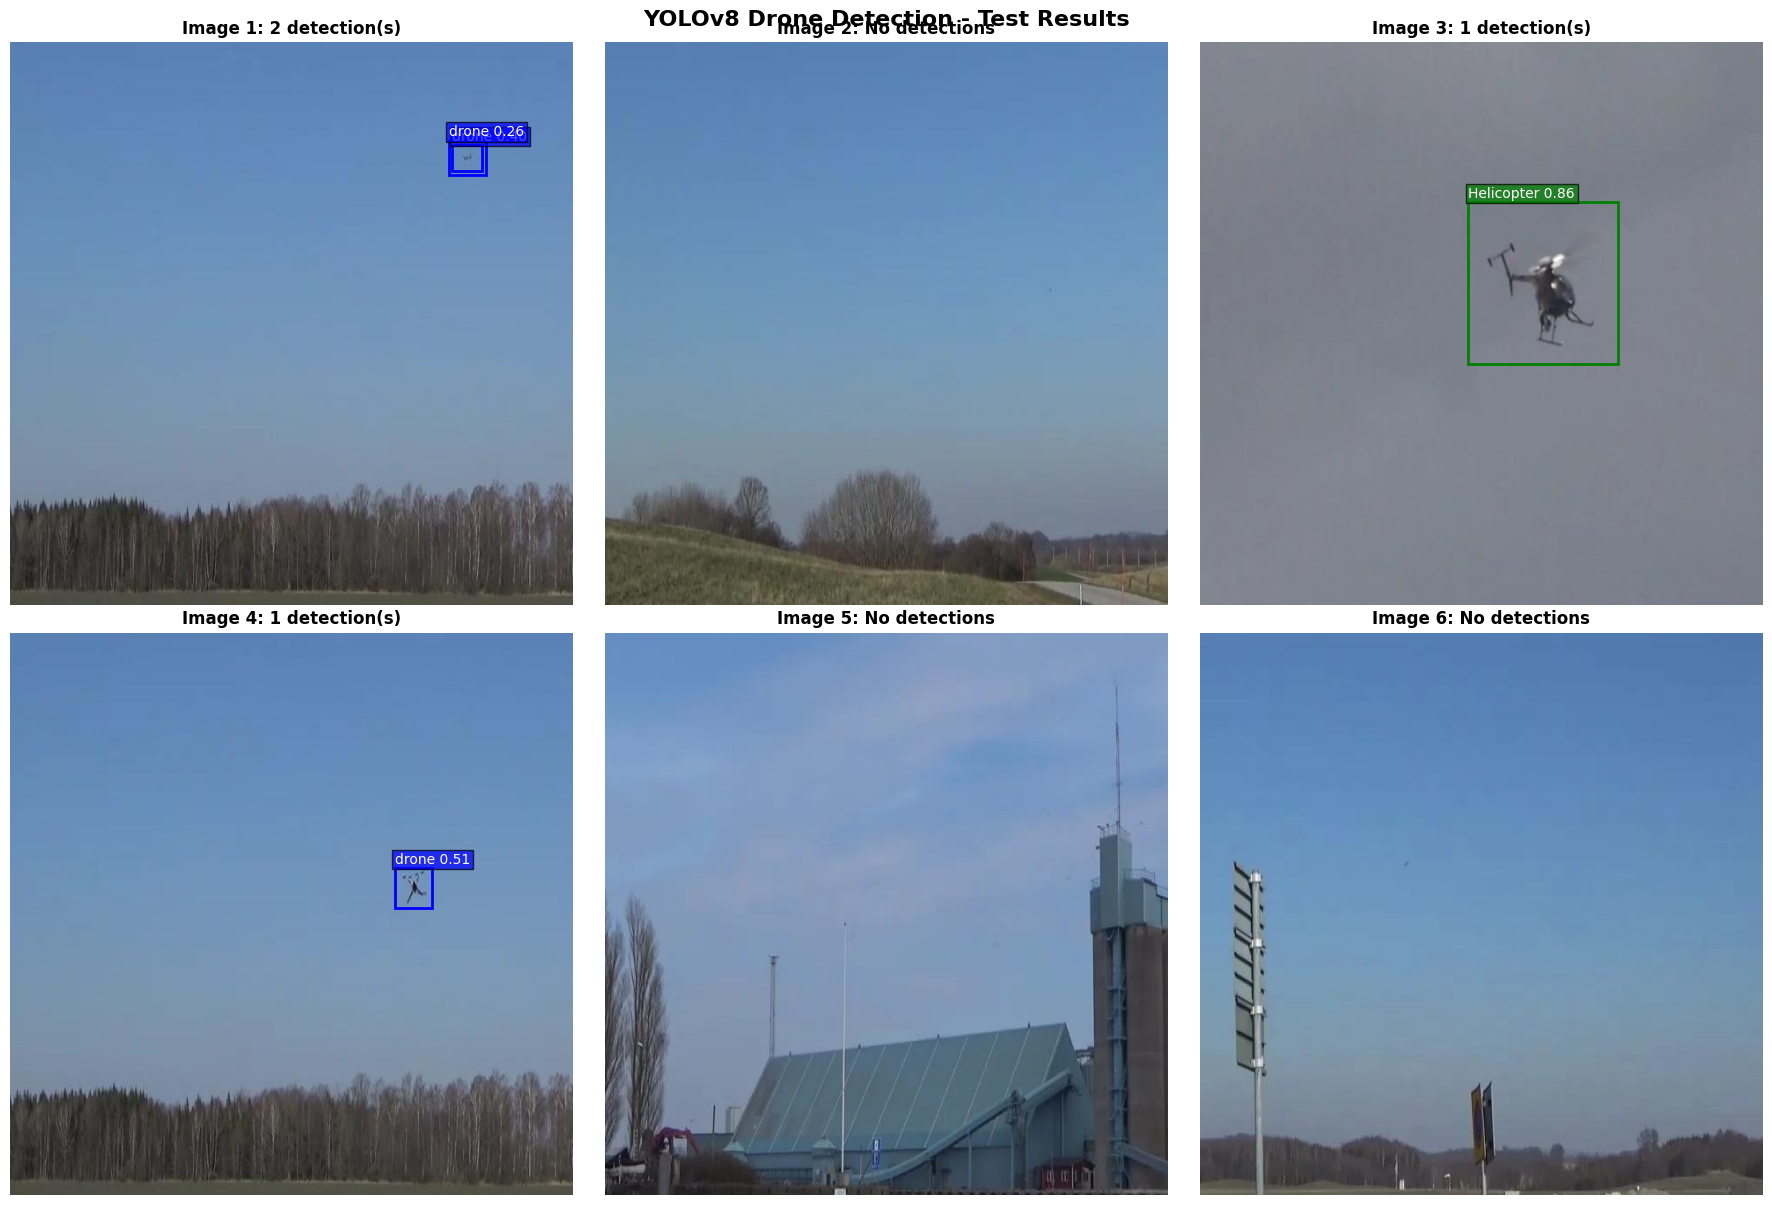


✓ Results displayed and saved to test_results_notebook.png


In [4]:
# Create figure
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, img_path in enumerate(random_images):
    # Run inference
    results = model(img_path, conf=CONFIDENCE_THRESHOLD, verbose=False)
    result = results[0]
    
    # Load and display image
    img = Image.open(img_path)
    img_array = np.array(img)
    axes[idx].imshow(img_array)
    axes[idx].axis('off')
    
    # Process detections
    boxes = result.boxes
    
    if len(boxes) > 0:
        print(f"\nImage {idx+1}: {os.path.basename(img_path)}")
        print(f"  Detected {len(boxes)} object(s):")
        
        for i, box in enumerate(boxes):
            # Get box info
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            confidence = float(box.conf[0])
            class_id = int(box.cls[0])
            class_name = CLASS_NAMES[class_id] if class_id < len(CLASS_NAMES) else f"Class {class_id}"
            
            print(f"    {i+1}. {class_name} ({confidence:.1%})")
            
            # Draw bounding box
            width, height = x2 - x1, y2 - y1
            color = COLORS[class_id % len(COLORS)]
            
            rect = patches.Rectangle(
                (x1, y1), width, height,
                linewidth=2, edgecolor=color, facecolor='none'
            )
            axes[idx].add_patch(rect)
            
            # Add label
            label = f"{class_name} {confidence:.2f}"
            axes[idx].text(
                x1, y1 - 5, label,
                color='white', fontsize=10,
                bbox=dict(facecolor=color, alpha=0.7, pad=2)
            )
        
        axes[idx].set_title(f"Image {idx+1}: {len(boxes)} detection(s)", fontweight='bold')
    else:
        axes[idx].set_title(f"Image {idx+1}: No detections", fontweight='bold')

# Hide unused subplots
for idx in range(len(random_images), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.suptitle('YOLOv8 Drone Detection - Test Results', fontsize=16, fontweight='bold', y=1.00)
plt.savefig('test_results_notebook.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Results displayed and saved to test_results_notebook.png")

In [6]:
# Specify your custom image path here
CUSTOM_IMAGE = "/Users/hilkin/.cache/kagglehub/datasets/cybersimar08/drone-detection/versions/3/drone-detection-new.v5-new-train.yolov8/valid/images/V_DRONE_096206_286_png.rf.ae52725c7e1bc44de657e1a2819f0de1.jpg"  # ← Change this!

# Run inference
results = model(CUSTOM_IMAGE, conf=0.30)

results[0].show()

boxes = results[0].boxes
print(f"\nDetected {len(boxes)} object(s):")
for i, box in enumerate(boxes):
    confidence = float(box.conf[0])
    class_id = int(box.cls[0])
    class_name = CLASS_NAMES[class_id]
    print(class_name)
    print(class_id)
    print(f"  {i+1}. {class_name} - Confidence: {confidence:.1%}")


Detected 1 object(s):
drone
1
  1. drone - Confidence: 53.9%


## Model Performance on Test Set

In [10]:
# Run full evaluation on test set
print("Running full test set evaluation...\n")

test_results = model.val(
    data="drone_data_yolov8.yaml",
    split='test',
    imgsz=512,
    batch=8,
    device='mps'
)

print("\n" + "="*60)
print("TEST SET PERFORMANCE")
print("="*60)
print(f"mAP50:     {test_results.results_dict.get('metrics/mAP50(B)', 0):.3f}")
print(f"mAP50-95:  {test_results.results_dict.get('metrics/mAP50-95(B)', 0):.3f}")
print(f"Precision: {test_results.results_dict.get('metrics/precision(B)', 0):.3f}")
print(f"Recall:    {test_results.results_dict.get('metrics/recall(B)', 0):.3f}")
print("="*60)

Running full test set evaluation...

Ultralytics 8.4.13 🚀 Python-3.14.2 torch-2.10.0 MPS (Apple M4)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 86.7±47.0 MB/s, size: 20.8 KB)
val: Scanning /Users/hilkin/.cache/kagglehub/datasets/cybersimar08/drone-detection/versions/3/drone-detection-new.v5-new-train.yolov8/test/labels.cache... 596 images, 123 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 596/596 96.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 75/75 3.9it/s 19.0s0.1ss
                   all        596        479      0.941      0.941      0.967      0.655
                 drone        128        128      0.952      0.938      0.988      0.716
              AirPlane        234        237      0.894      0.895      0.923      0.489
                 Drone        111        114      0.977      0.991       0.99      0.761
Speed: 0.2ms preprocess, 10.0ms inference, 0.0ms loss, 10.3ms postprocess per image
Results sa

## Quick Reference

**What the metrics mean:**
- **mAP50**: Mean Average Precision at 50% IoU threshold (0-1, higher is better)
- **mAP50-95**: Average mAP from 50% to 95% IoU (more strict, 0-1)
- **Precision**: How many detections were correct (0-1)
- **Recall**: How many actual objects were detected (0-1)

**Good scores:**
- mAP50 > 0.90 = Excellent 🌟
- mAP50 > 0.80 = Good ✅
- mAP50 > 0.70 = Acceptable 👍

**Your model files:**
- Best model: `runs/detect/drone_yolov8_results/mac_m4_notebook/weights/best.pt`
- Last checkpoint: `runs/detect/drone_yolov8_results/mac_m4_notebook/weights/last.pt`
- Training plots: `runs/detect/drone_yolov8_results/mac_m4_notebook/*.png`